860 image, 2 esp, 10 k, 1 seg 

In [9]:
import pandas as pd
import re
from IPython.display import display, Markdown
import numpy as np

CSV_PATH = f"../results/exp_2/combined_results.csv"
df = pd.read_csv(CSV_PATH)

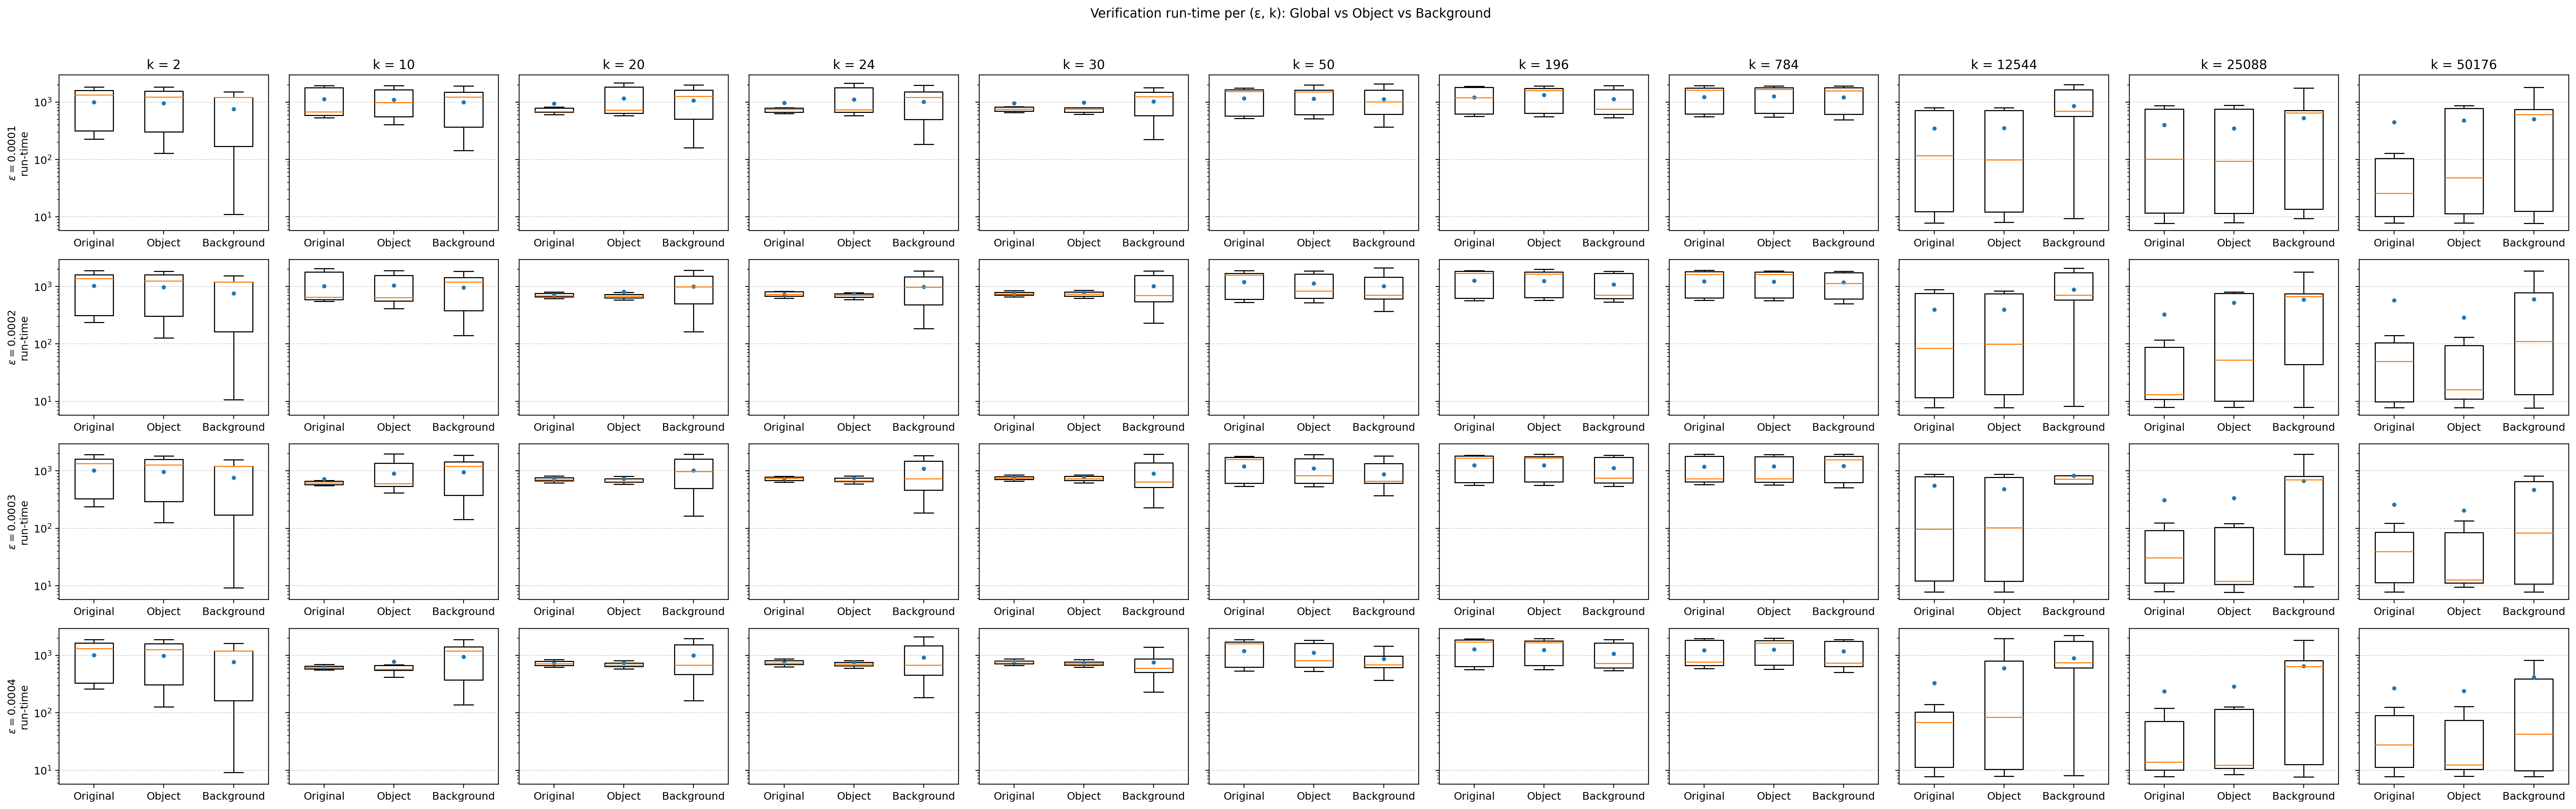

In [10]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Helpers
# ---------------------------
TIME_COL = "all_time" if "all_time" in df.columns else "bab_time"

def filter_by_tag_contains(frame: pd.DataFrame, include_any=(), include_all=(), exclude_any=()):
    tag = frame["tag"].astype(str)
    keep = pd.Series(True, index=frame.index)

    if include_any:
        keep_any = pd.Series(False, index=frame.index)
        for s in include_any:
            keep_any |= tag.str.contains(s, case=False, na=False)
        keep &= keep_any

    for s in include_all:
        keep &= tag.str.contains(s, case=False, na=False)

    if exclude_any:
        for s in exclude_any:
            keep &= ~tag.str.contains(s, case=False, na=False)

    return frame[keep].copy()

def sanitize_numeric(frame: pd.DataFrame):
    out = frame.copy()
    out["eps"] = pd.to_numeric(out["eps"], errors="coerce")
    out["k"] = pd.to_numeric(out["k"], errors="coerce")
    out[TIME_COL] = pd.to_numeric(out[TIME_COL], errors="coerce")
    out = out.dropna(subset=["eps", "k", TIME_COL]).copy()
    out = out[out[TIME_COL] > 0].copy()
    return out

def grouped_boxplot_one_panel(ax, triplet_data, labels, show_means=True):
    """
    triplet_data: [global_times, object_times, background_times]
    """
    ax.boxplot(triplet_data, tick_labels=labels, showfliers=False, widths=0.55)

    if show_means:
        means = [np.mean(v) if len(v) else np.nan for v in triplet_data]
        ax.plot([1, 2, 3], means, marker="o", linestyle="none", markersize=3)

    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# ---------------------------
# Build subsets (KEEPING YOUR STYLE, but FIXED SEMANTICS)
# ---------------------------

# Global
if "is_global" in df.columns:
    df_global = df[df["is_global"] == True].copy()
else:
    df_global = filter_by_tag_contains(df, include_any=("global",))

# Object verification = fix_nonmask (background fixed)
# (your previous "seg + mask excluding non-mask" was unreliable)
df_object = filter_by_tag_contains(df, include_any=("fixnonmask", "fix_nonmask", "fix_non_mask"))

# Background verification = fix_mask (object fixed)
df_background = filter_by_tag_contains(df, include_any=("fixmask", "fix_mask"))

# Sanitize
df_global = sanitize_numeric(df_global)
df_object = sanitize_numeric(df_object)
df_background = sanitize_numeric(df_background)

# ---------------------------
# Decide which eps and k to plot (12 panels)
# ---------------------------
# Use common eps across all three so panels are comparable
eps_vals = sorted(set(df_global["eps"]) & set(df_object["eps"]) & set(df_background["eps"]))

# Use common k across all three
k_vals = sorted(set(df_global["k"]) & set(df_object["k"]) & set(df_background["k"]))

# If you want EXACTLY 4 eps × 3 k = 12 panels, trim here if needed:
# eps_vals = eps_vals[:4]
# k_vals = k_vals[:3]

# ---------------------------
# Plot grid: rows=eps, cols=k  (=> 4x3 = 12)
# ---------------------------
rows = len(eps_vals)
cols = len(k_vals)

fig, axes = plt.subplots(rows, cols, figsize=(cols*3.1, rows*2.6), dpi=220, sharey=True)
axes = np.array(axes).reshape(rows, cols)

xlabels = [
    "Original",
    "Object",
    "Background",
]

for i, eps in enumerate(eps_vals):
    for j, k in enumerate(k_vals):
        ax = axes[i, j]

        g = df_global[(df_global["eps"] == eps) & (df_global["k"] == k)][TIME_COL].values
        o = df_object[(df_object["eps"] == eps) & (df_object["k"] == k)][TIME_COL].values
        b = df_background[(df_background["eps"] == eps) & (df_background["k"] == k)][TIME_COL].values

        grouped_boxplot_one_panel(ax, [g, o, b], xlabels, show_means=True)

        # Titles: keep compact
        if i == 0:
            ax.set_title(f"k = {int(k)}")
        if j == 0:
            ax.set_ylabel(rf"$\epsilon={eps:g}$" + "\nrun-time")

        ax.set_yscale("log")

# overall title
fig.suptitle("Verification run-time per (ε, k): Global vs Object vs Background", y=1.02)

plt.tight_layout()
plt.show()

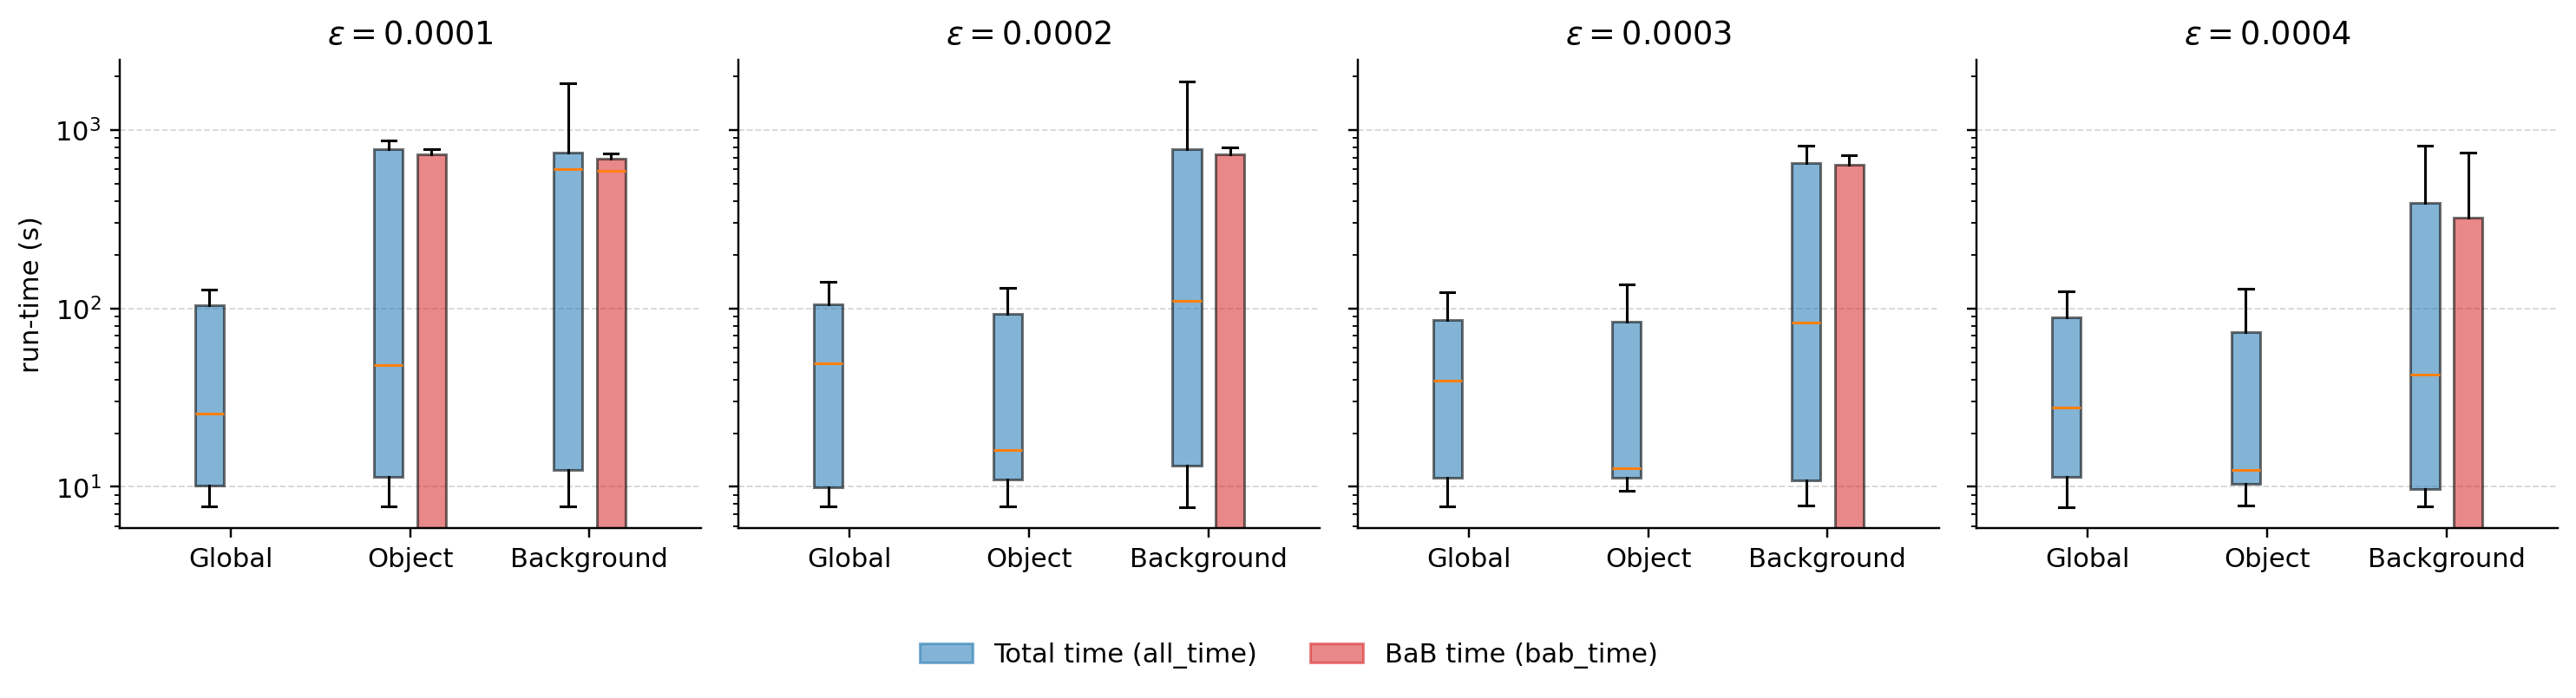

In [11]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------
# Helpers
# ---------------------------
ALL_COL = "all_time"
BAB_COL = "bab_time"

def filter_by_tag_contains(frame: pd.DataFrame, include_any=(), include_all=(), exclude_any=()):
    tag = frame["tag"].astype(str)
    keep = pd.Series(True, index=frame.index)

    if include_any:
        keep_any = pd.Series(False, index=frame.index)
        for s in include_any:
            keep_any |= tag.str.contains(s, case=False, na=False)
        keep &= keep_any

    for s in include_all:
        keep &= tag.str.contains(s, case=False, na=False)

    if exclude_any:
        for s in exclude_any:
            keep &= ~tag.str.contains(s, case=False, na=False)

    return frame[keep].copy()

def sanitize_numeric(frame: pd.DataFrame):
    out = frame.copy()
    out["eps"] = pd.to_numeric(out["eps"], errors="coerce")
    out["k"] = pd.to_numeric(out["k"], errors="coerce")
    out[ALL_COL] = pd.to_numeric(out[ALL_COL], errors="coerce")
    if BAB_COL in out.columns:
        out[BAB_COL] = pd.to_numeric(out[BAB_COL], errors="coerce")

    out = out.dropna(subset=["eps", "k", ALL_COL]).copy()
    out = out[out[ALL_COL] > 0].copy()

    if BAB_COL in out.columns:
        out[BAB_COL] = out[BAB_COL].fillna(0)
        out.loc[out[BAB_COL] < 0, BAB_COL] = 0

    return out

def paired_boxplot_one_panel(ax, data_pairs, base_labels):
    centers = np.arange(1, len(base_labels) + 1)

    pos_total = centers - 0.12
    pos_bab   = centers + 0.12

    total_data = [p[0] for p in data_pairs]
    bab_data   = [p[1] for p in data_pairs]

    bp1 = ax.boxplot(
        total_data, positions=pos_total, widths=0.16,
        showfliers=False, patch_artist=True
    )
    bp2 = ax.boxplot(
        bab_data, positions=pos_bab, widths=0.16,
        showfliers=False, patch_artist=True
    )

    for b in bp1["boxes"]:
        b.set_facecolor("#1f77b4")
        b.set_alpha(0.55)
    for b in bp2["boxes"]:
        b.set_facecolor("#d62728")
        b.set_alpha(0.55)

    for key in ["whiskers", "caps", "medians"]:
        for line in bp1[key]:
            line.set_linewidth(1.0)
        for line in bp2[key]:
            line.set_linewidth(1.0)

    ax.set_xticks(centers)
    ax.set_xticklabels(base_labels)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

# ---------------------------
# Build subsets
# ---------------------------
if "is_global" in df.columns:
    df_global = df[df["is_global"] == True].copy()
else:
    df_global = filter_by_tag_contains(df, include_any=("global",))

df_object = filter_by_tag_contains(df, include_any=("fixnonmask", "fix_nonmask", "fix_non_mask"))
df_background = filter_by_tag_contains(df, include_any=("fixmask", "fix_mask"))

df_global = sanitize_numeric(df_global)
df_object = sanitize_numeric(df_object)
df_background = sanitize_numeric(df_background)

# ---------------------------
# FIXED k silently
# ---------------------------
FIXED_K = 50176

df_global = df_global[df_global["k"] == FIXED_K]
df_object = df_object[df_object["k"] == FIXED_K]
df_background = df_background[df_background["k"] == FIXED_K]

# ---------------------------
# TWO EPS SIDE BY SIDE
# ---------------------------

eps_vals = sorted(eps_vals)

cols = len(eps_vals)
rows = 1

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 3.4, 3.2),
    dpi=220,
    sharey=True,
)

axes = np.array(axes).reshape(1, cols)

base_labels = ["Global", "Object", "Background"]

for j, eps in enumerate(eps_vals):

    ax = axes[0, j]

    g_all = df_global[df_global["eps"] == eps][ALL_COL].values
    g_bab = df_global[df_global["eps"] == eps][BAB_COL].values

    o_all = df_object[df_object["eps"] == eps][ALL_COL].values
    o_bab = df_object[df_object["eps"] == eps][BAB_COL].values

    b_all = df_background[df_background["eps"] == eps][ALL_COL].values
    b_bab = df_background[df_background["eps"] == eps][BAB_COL].values

    paired_boxplot_one_panel(
        ax,
        data_pairs=[(g_all, g_bab), (o_all, o_bab), (b_all, b_bab)],
        base_labels=base_labels
    )

    ax.set_title(rf"$\epsilon={eps:g}$")

    ax.set_yscale("log")

    if j == 0:
        ax.set_ylabel("run-time (s)")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ---------------------------
# Title + legend
# ---------------------------

# fig.suptitle(
#    "Verification run-time per ε: total time with embedded BaB time",
#    y=1.05
# )

total_patch = mpatches.Patch(color="#1f77b4", alpha=0.55, label="Total time (all_time)")
bab_patch   = mpatches.Patch(color="#d62728", alpha=0.55, label="BaB time (bab_time)")

fig.legend(
    handles=[total_patch, bab_patch],
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15),
)

plt.tight_layout()
plt.show()

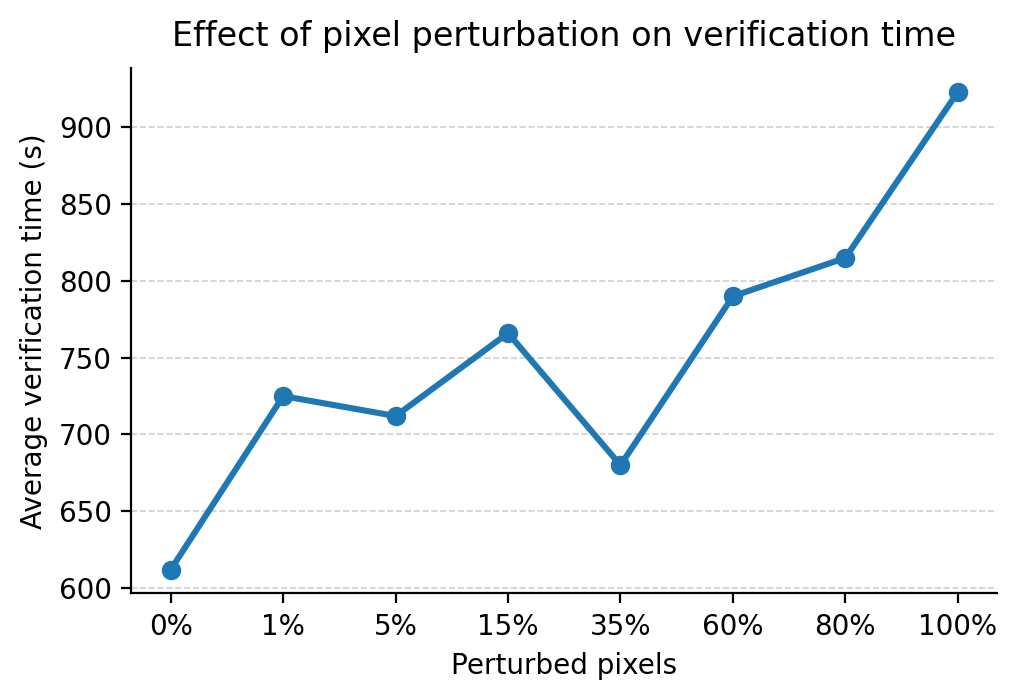

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ---- your aggregated data (example) ----
pixel_vals = np.array([0, 1, 5, 15, 35, 60, 80, 100])
avg_time = np.array([612, 725, 712, 766, 680, 790, 815, 923])

# ---- categorical x positions (equal spacing) ----
x_pos = np.arange(len(pixel_vals))

# ---- plot ----
plt.figure(figsize=(5.2, 3.6), dpi=200)

plt.plot(
    x_pos,
    avg_time,
    marker="o",
    linewidth=2.2,
    markersize=6,
)

# ---- axis styling ----
plt.xticks(x_pos, [f"{p}%" for p in pixel_vals])
plt.xlabel("Perturbed pixels")
plt.ylabel("Average verification time (s)")

plt.title("Effect of pixel perturbation on verification time", pad=8)

# subtle grid (y only)
plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# remove top/right spines (paper style)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

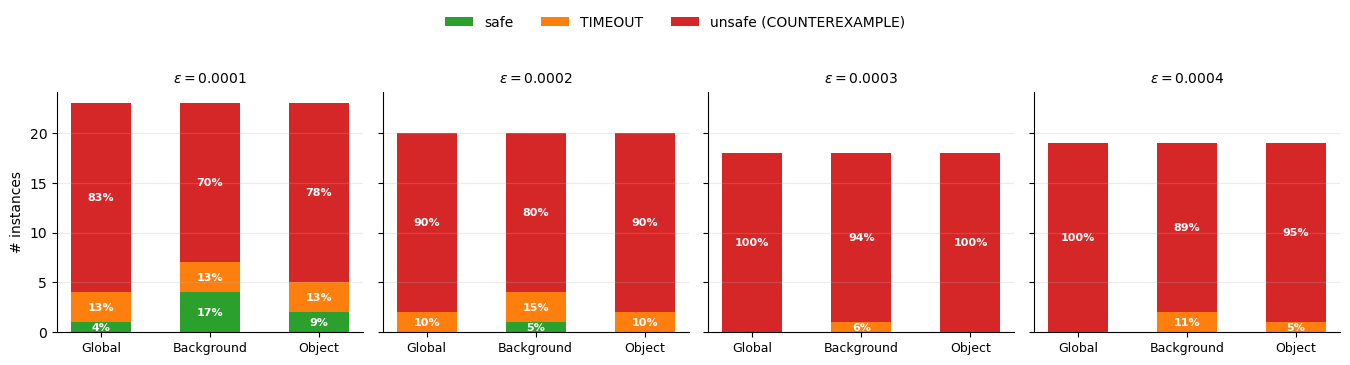

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
PAIR_COLS = ["image", "eps", "k"]

VARIANTS = ["Global", "Background", "Object"]
XTICK_LABELS = ["Global", "Background", "Object"]

RESULT_RENAME = {
    "unsat False": "safe",
    "timeout False": "TIMEOUT",
    "sat True": "unsafe (COUNTEREXAMPLE)",
}

RESULT_COLORS = {
    "unsafe (COUNTEREXAMPLE)": "#d62728",
    "safe": "#2ca02c",
    "TIMEOUT": "#ff7f0e",
}

RESULT_ORDER = ["safe", "TIMEOUT", "unsafe (COUNTEREXAMPLE)"]

FIXED_K = 50176   # silently restrict to this

# -----------------------------
# LOAD / CLEAN
# -----------------------------
df = df.copy()
df["eps"] = pd.to_numeric(df["eps"], errors="coerce")
df["k"]   = pd.to_numeric(df["k"], errors="coerce")
df["result"] = df["result"].astype(str)

# -----------------------------
# VARIANT CLASSIFIER
# -----------------------------
def classify_variant(row):
    pat = str(row.get("pattern", "")).lower()
    tag = str(row.get("tag", "")).lower()
    vnn = str(row.get("vnnlib", "")).lower()
    is_global = bool(row.get("is_global", False))

    if is_global or pat == "global" or "_global" in tag or "_global" in vnn:
        return "Global"

    s = " ".join([pat, tag, vnn])

    if any(k in s for k in ["fix_mask", "fix-mask", "fixmask"]):
        return "Background"
    if any(k in s for k in ["fix_nonmask", "fix-nonmask", "fixnonmask", "fix_non_mask"]):
        return "Object"

    if any(k in s for k in ["background", "bg", "nonmask", "non-mask"]):
        return "Background"
    if any(k in s for k in [" object", " obj", "foreground"]):
        return "Object"

    return None

df["variant"] = df.apply(classify_variant, axis=1)
df = df[df["variant"].isin(VARIANTS)].copy()

# Keep only seg0 for non-global
if "segment_index" in df.columns:
    df = df[(df["variant"] == "Global") | (df["segment_index"] == 0)].copy()

# Clean results
df = df[df["result"].isin(RESULT_RENAME)].copy()
df["result_clean"] = df["result"].map(RESULT_RENAME)

# -----------------------------
# PAIRED WIDE TABLE
# -----------------------------
res_all3 = df.pivot_table(
    index=PAIR_COLS,
    columns="variant",
    values="result_clean",
    aggfunc="first"
).reset_index()

res_all3 = res_all3.dropna(subset=VARIANTS).copy()

# -----------------------------
# FIX k SILENTLY
# -----------------------------
res_all3 = res_all3[res_all3["k"] == FIXED_K].copy()

# -----------------------------
# EPS PANELS SIDE BY SIDE
# -----------------------------
eps_values = sorted(res_all3["eps"].dropna().unique())

rows = 1
cols = len(eps_values)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 3.4, 3.4),
    squeeze=False,
    sharey=True
)

x = np.arange(len(VARIANTS))

for j, eps in enumerate(eps_values):

    ax = axes[0][j]
    sub = res_all3[res_all3["eps"] == eps]

    bottom = np.zeros(len(VARIANTS), dtype=float)

    total_per_variant = np.array([len(sub)] * len(VARIANTS), dtype=float)

    for lab in RESULT_ORDER:

        vals = np.array([(sub[v] == lab).sum() for v in VARIANTS], dtype=float)
        pct  = np.divide(vals, total_per_variant, out=np.zeros_like(vals), where=total_per_variant > 0) * 100

        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.55,
            color=RESULT_COLORS[lab],
            label=lab if j == 0 else None,
        )

        # percentage text
        for xi, v, p, btm in zip(x, vals, pct, bottom):
            if v > 0:
                ax.text(
                    xi,
                    btm + v / 2,
                    f"{p:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    weight="bold",
                )

        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(XTICK_LABELS, fontsize=9)
    ax.grid(True, axis="y", alpha=0.25)

    ax.set_title(rf"$\epsilon = {eps:g}$", fontsize=10)

    if j == 0:
        ax.set_ylabel("# instances", fontsize=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# -----------------------------
# Legend + title
# -----------------------------
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.08),
)

# fig.suptitle( "Outcome distribution by variant (fully paired by image and ε)", y=1.18, fontsize=11,)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [14]:
import numpy as np
import pandas as pd

IMAGE_COL   = "image"
EPS_COL     = "eps"
VARIANT_COL = "variant"
LABEL_COL   = "result_label"

def build_panel(df_eps: pd.DataFrame, eps_val: float):

    d = df_eps.copy()

    # -----------------------------------------
    # BASELINE = images whose GLOBAL failed
    # using glb_status (not variant==global)
    # -----------------------------------------
    g = (
        d[[IMAGE_COL, "glb_status"]]
        .drop_duplicates(subset=[IMAGE_COL])
    )

    base_fail = set(
        g[g["glb_status"] != "Safe (proved)"][IMAGE_COL]
    )

    n_base = len(base_fail)

    # -----------------------------------------
    # pivot by (image, segment)
    # -----------------------------------------
    d = d.drop_duplicates(
        subset=[IMAGE_COL, VARIANT_COL, SEG_COL],
        keep="last"
    )

    lab = d.pivot_table(
        index=[IMAGE_COL, SEG_COL],
        columns=VARIANT_COL,
        values=LABEL_COL,
        aggfunc="last"
    )

    counts, names = {}, {}

    for (src, dst) in TRANS_ORDER:

        counts[(src, dst)] = {}
        names[(src, dst)]  = {}

        for v in variants:

            if v not in lab.columns:
                counts[(src, dst)][v] = 0
                names[(src, dst)][v]  = []
                continue

            idx = lab.index

            imgs = idx.get_level_values(0)

            # baseline restriction
            mask_base = imgs.isin(base_fail)

            # transition logic:
            ok_global = d.drop_duplicates(
                subset=[IMAGE_COL]
            ).set_index(IMAGE_COL)["glb_status"].reindex(imgs).values == src

            ok_var = lab[v].values == dst

            picked_imgs = sorted(
                set(imgs[mask_base & ok_global & ok_var])
            )

            counts[(src, dst)][v] = len(picked_imgs)
            names[(src, dst)][v]  = picked_imgs

    # -----------------------------------------
    # intersection object ∩ background
    # -----------------------------------------
    both = {}
    for (src, dst) in TRANS_ORDER:
        both[(src, dst)] = sorted(
            set(names[(src, dst)]["object"])
            &
            set(names[(src, dst)]["background"])
        )

    return {
        "eps": eps_val,
        "n_base": n_base,
        "counts": counts,
        "names": names,
        "both": both,
    }

---- NaN rates (Object/Background/Both) ----
Object        0.196605
Background    0.093352
Both          0.012730
dtype: float64

---- Rows where BOTH is defined (Object+Background available) ----
count = 28
                      image                                 tag     eps  \
10      n01531178_goldfinch    n01531178_goldfinch_seg0_fixmask  0.0001   
50          n01534433_junco        n01534433_junco_seg0_fixmask  0.0001   
94          n01558993_robin              n01558993_robin_global  0.0001   
138        n01560419_bulbul             n01560419_bulbul_global  0.0001   
182           n01580077_jay          n01580077_jay_seg0_fixmask  0.0001   
223        n01582220_magpie       n01582220_magpie_seg0_fixmask  0.0001   
266     n01592084_chickadee    n01592084_chickadee_seg0_fixmask  0.0001   
308           n01631663_eft          n01631663_eft_seg0_fixmask  0.0001   
350      n01641577_bullfrog     n01641577_bullfrog_seg0_fixmask  0.0001   
394      n01667778_terrapin     n01667778_

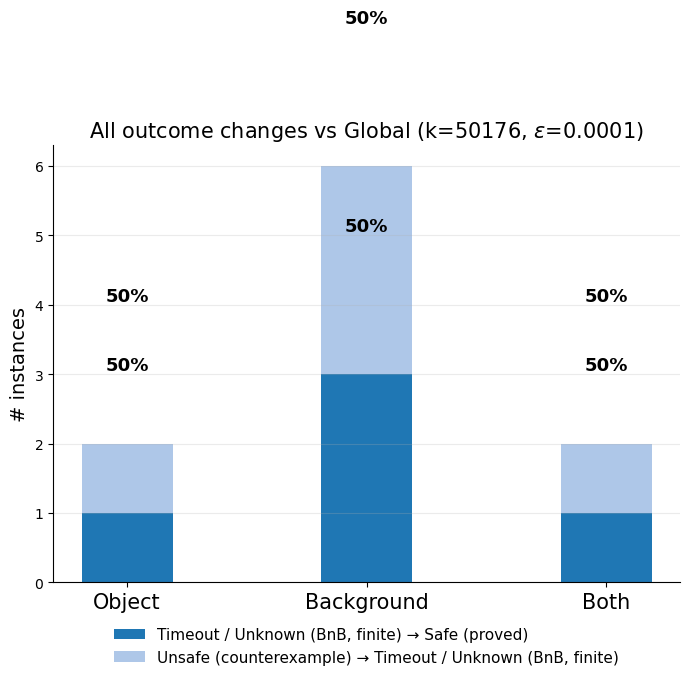

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================
PAIR_COLS = ["image", "eps", "k"]
VARIANT_COL = "variant"          # Global / Object / Background
TARGET_K = 50176
TARGET_EPS = 0.0001

# ============================================================
# 1) CLEAN + FLAGS
# ============================================================
d = df.copy()

d["eps"] = pd.to_numeric(d["eps"], errors="coerce")
d["k"]   = pd.to_numeric(d["k"], errors="coerce")
d["lb_minus_rhs"] = pd.to_numeric(d["lb_minus_rhs"], errors="coerce")

assert "domains_visited" in d.columns
d["bnb_entered"] = pd.to_numeric(d["domains_visited"], errors="coerce").fillna(0) > 0

d["glb_status"] = np.where(
    np.isfinite(d["lb_minus_rhs"]),
    "Finite lower bound",
    "Lower bound = -inf"
)

RESULT_RENAME = {
    "sat True": "Unsafe (counterexample)",
    "unsat False": "Safe (proved)",
    "timeout False": "Timeout / Unknown",
    "error": "Error",
    "sat False": "Unsafe (counterexample with BnB)",
}
d["result_label"] = d["result"].astype(str).str.strip().map(RESULT_RENAME).fillna(d["result"].astype(str))

# ============================================================
# 2) CANONICAL OUTCOME (matches your table logic)
# ============================================================
def canon_outcome(row):
    rl = str(row["result_label"]).strip()
    b  = bool(row["bnb_entered"])
    g  = str(row["glb_status"]).strip()

    if rl == "Error":
        return "Error"

    if rl == "Safe (proved)":
        return "Safe (proved)"

    if rl == "Unsafe (counterexample)":
        return "Unsafe (counterexample)"

    if rl == "Unsafe (counterexample with BnB)":
        return "Unsafe (counterexample with BnB)"

    if rl == "Timeout / Unknown":
        # keep the two timeout rows you had in your summary table
        if b and g == "Finite lower bound":
            return "Timeout / Unknown (BnB, finite)"
        else:
            return "Timeout / Unknown (no bound)"

    # fallback (rare)
    return "Timeout / Unknown (no bound)"

d["outcome"] = d.apply(canon_outcome, axis=1)

# ============================================================
# 3) PIVOT: one outcome per (image, eps, k, variant)
# ============================================================
if VARIANT_COL not in d.columns:
    raise KeyError(f"Missing column '{VARIANT_COL}'.")

one = (
    d.groupby(PAIR_COLS + [VARIANT_COL], as_index=False)["outcome"]
     .agg(lambda x: x.iloc[0])
)

wide = one.pivot_table(
    index=PAIR_COLS,
    columns=VARIANT_COL,
    values="outcome",
    aggfunc="first"
).reset_index()

if "Global" not in wide.columns:
    raise ValueError("No 'Global' variant found in your data.")

# ============================================================
# 3.5) SYNTHETIC BOTH = worst-case(Object, Background)
# ============================================================
severity = {
    "Safe (proved)": 0,
    "Timeout / Unknown (no bound)": 1,
    "Timeout / Unknown (BnB, finite)": 2,
    "Unsafe (counterexample)": 3,
    "Unsafe (counterexample with BnB)": 4,
    "Error": 5,
}

def worst_case(a, b):
    if pd.isna(a) and pd.isna(b):
        return np.nan
    if pd.isna(a):
        return b
    if pd.isna(b):
        return a
    return a if severity.get(a, -1) >= severity.get(b, -1) else b

# You have Object + Background in the CSV; create Both from them
if ("Object" in wide.columns) and ("Background" in wide.columns):
    wide["Both"] = [worst_case(a, b) for a, b in zip(wide["Object"], wide["Background"])]
else:
    raise ValueError("Need both Object and Background columns in wide to build synthetic Both.")

# ============================================================
# 4) ADD TAG (and optionally other columns) BACK TO wide
# ============================================================
# Tag is per image (usually stable). We pick the most frequent tag per image.
if "tag" in d.columns:
    tag_map = (
        d.dropna(subset=["tag"])
         .groupby("image")["tag"]
         .agg(lambda s: s.astype(str).value_counts().index[0])
         .reset_index()
    )
    wide = wide.merge(tag_map, on="image", how="left")
else:
    wide["tag"] = np.nan

# ============================================================
# 5) LIST "IMAGES/TAGS THAT ARE IN BOTH"
# Meaning: rows where Object and Background exist (so Both is meaningful)
# ============================================================
both_rows = wide[
    (wide["k"] == TARGET_K) &
    (wide["eps"] == TARGET_EPS) &
    (wide["Object"].notna()) &
    (wide["Background"].notna())
].copy()

print("---- NaN rates (Object/Background/Both) ----")
print(wide[["Object","Background","Both"]].isna().mean())

print("\n---- Rows where BOTH is defined (Object+Background available) ----")
print("count =", len(both_rows))

# show a compact table
show_cols = ["image", "tag", "eps", "k", "Global", "Object", "Background", "Both"]
print(both_rows[show_cols].head(25))

# also: which ones actually CHANGE when using BOTH vs Global?
both_change = both_rows[both_rows["Both"] != both_rows["Global"]].copy()
print("\n---- Rows where BOTH differs from Global (i.e., BOTH causes a change) ----")
print("count =", len(both_change))
print(both_change[show_cols].head(25))

# if you want the full list of names (no truncation):
print("\nImage names where BOTH is defined:")
print(both_rows["image"].tolist())

print("\nImage+tag where BOTH differs from Global:")
print(list(zip(both_change["image"].tolist(), both_change["tag"].tolist())))

# ============================================================
# 5.5) PRINT IMAGE NAMES PER OUTCOME CATEGORY (per variant)
# ============================================================
slice_w = wide[(wide["k"] == TARGET_K) & (wide["eps"] == TARGET_EPS)].copy()

variants_to_report = ["Global", "Object", "Background", "Both"]
variants_to_report = [v for v in variants_to_report if v in slice_w.columns]

for v in variants_to_report:
    print("\n" + "="*80)
    print(f"[{v}] image names per OUTCOME category  (k={TARGET_K}, eps={TARGET_EPS})")
    print("="*80)

    # group -> list images (and tags)
    g = (
        slice_w.dropna(subset=[v])
              .groupby(v)
              .agg(
                  n_images=("image", "nunique"),
                  images=("image", lambda s: sorted(s.unique())),
                  tags=("tag", lambda s: sorted(pd.Series(s.dropna().astype(str).unique()).tolist()))
              )
              .reset_index()
              .rename(columns={v: "outcome"})
    )

    # print nicely
    for _, row in g.sort_values("n_images", ascending=False).iterrows():
        outcome = row["outcome"]
        n = int(row["n_images"])
        imgs = row["images"]
        print(f"\n- {outcome}  (n={n})")
        print("  images:", imgs)   # full list

# ============================================================
# 6) BUILD TRANSITIONS vs GLOBAL FOR PLOTTING (Object/Background/Both)
# ============================================================
sem_vars = [c for c in ["Object", "Background", "Both"] if c in wide.columns]
long = wide.melt(
    id_vars=["image", "tag", "eps", "k", "Global"],
    value_vars=sem_vars,
    var_name="Semantic",
    value_name="SemanticOutcome"
).dropna(subset=["Global", "SemanticOutcome"])

long["transition"] = long["Global"].astype(str) + " → " + long["SemanticOutcome"].astype(str)

# ONLY CHANGES (you can set to False if you want all)
ONLY_CHANGES = True
if ONLY_CHANGES:
    long = long[long["Global"] != long["SemanticOutcome"]].copy()

# restrict to your slice
long = long[(long["k"] == TARGET_K) & (long["eps"] == TARGET_EPS)].copy()
if long.empty:
    raise ValueError("No transitions found for the requested (k, eps) slice.")

den = (
    long.groupby(["Semantic"], as_index=False)
        .size()
        .rename(columns={"size": "den"})
)

cnt = (
    long.groupby(["Semantic", "transition"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
).merge(den, on=["Semantic"], how="left")

cnt["pct_total"] = np.where(cnt["den"] > 0, 100.0 * cnt["count"] / cnt["den"], 0.0)

# transition order by frequency
trans_order = (
    cnt.groupby("transition")["count"].sum()
       .sort_values(ascending=False)
       .index.tolist()
)

# ============================================================
# 7) PLOT (TALL + THIN BARS + LEGEND DOWN)
# ============================================================
xlabels = ["Object", "Background", "Both"]
xlabels = [s for s in xlabels if s in cnt["Semantic"].unique()]  # only present
x = np.arange(len(xlabels))

BAR_WIDTH = 0.38
FIG_W = 7.0
FIG_H = 9.5          # <-- taller
MIN_LABEL_PCT = 1.0  # show more % labels

# colors
tab = list(plt.get_cmap("tab20").colors)
colors = tab if len(trans_order) <= len(tab) else tab + [
    plt.get_cmap("hsv")(i/len(trans_order)) for i in range(len(trans_order)-len(tab))
]
COLOR_MAP = {t: colors[i] for i, t in enumerate(trans_order)}

lut = {(r["Semantic"], r["transition"]): (float(r["count"]), float(r["pct_total"]))
       for _, r in cnt.iterrows()}

plt.figure(figsize=(FIG_W, FIG_H))
ax = plt.gca()
bottom = np.zeros(len(xlabels), dtype=float)

for trans in trans_order:
    vals = np.array([lut.get((sem, trans), (0.0, 0.0))[0] for sem in xlabels], dtype=float)
    if vals.sum() == 0:
        continue

    bars = ax.bar(x, vals, bottom=bottom, color=COLOR_MAP[trans], label=trans, width=BAR_WIDTH)

    for i, b in enumerate(bars):
        h = b.get_height()
        if h <= 0:
            continue
        pct = lut.get((xlabels[i], trans), (0.0, 0.0))[1]
        if pct < MIN_LABEL_PCT:
            continue

        # readable labels
        if h >= 8:
            y = bottom[i] + h/2.0
            va = "center"
            txt_color = "white"
        else:
            y = bottom[i] + h + 2.0
            va = "bottom"
            txt_color = "black"

        ax.text(
            b.get_x() + b.get_width()/2.0,
            y,
            f"{pct:.0f}%",
            ha="center",
            va=va,
            fontsize=13,
            color=txt_color,
            fontweight="bold"
        )

    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=15)
ax.set_ylabel("# instances", fontsize=14)
ax.set_title(rf"All outcome changes vs Global (k={TARGET_K}, $\varepsilon$={TARGET_EPS:g})", fontsize=15)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# legend DOWN
handles, labels = ax.get_legend_handles_labels()
ncol = min(3, max(1, int(np.ceil(len(labels) / 2))))
plt.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=ncol,
    frameon=False,
    fontsize=11
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

In [16]:
# ============================================================
# PRINT IMAGE NAMES PER TRANSITION (and semantic)
# ============================================================
# long already has: image, tag, eps, k, Global, Semantic, SemanticOutcome, transition

# restrict to your slice (same as your plotting slice)
long_slice = long[(long["k"] == TARGET_K) & (long["eps"] == TARGET_EPS)].copy()

# if you only want changes (same as plot)
ONLY_CHANGES = True
if ONLY_CHANGES:
    long_slice = long_slice[long_slice["Global"] != long_slice["SemanticOutcome"]].copy()

if long_slice.empty:
    print("No transitions found in this slice.")
else:
    # sort transitions by frequency (nice printing order)
    trans_order_print = (
        long_slice.groupby(["Semantic", "transition"])
                  .size()
                  .sort_values(ascending=False)
                  .reset_index(name="count")
    )

    for _, r in trans_order_print.iterrows():
        sem = r["Semantic"]
        trans = r["transition"]
        count = int(r["count"])

        

        rows = long_slice[(long_slice["Semantic"] == sem) & (long_slice["transition"] == trans)].copy()

        # unique image/tag pairs (avoid duplicates)
        pairs = (
            rows[["image", "tag"]]
            .drop_duplicates()
            .sort_values(["tag", "image"])
        )

        print("\n" + "="*90)
        print(f"{sem} | {trans} | n={count}")
        print("="*90)
        print(pairs.to_string(index=False))


Background | Timeout / Unknown (BnB, finite) → Safe (proved) | n=3
              image                              tag
    n01534433_junco     n01534433_junco_seg0_fixmask
   n01582220_magpie    n01582220_magpie_seg0_fixmask
n01592084_chickadee n01592084_chickadee_seg0_fixmask

Background | Unsafe (counterexample) → Timeout / Unknown (BnB, finite) | n=3
              image                              tag
    n01558993_robin           n01558993_robin_global
    n01687978_agama     n01687978_agama_seg0_fixmask
n01768244_trilobite n01768244_trilobite_seg0_fixmask

Both | Timeout / Unknown (BnB, finite) → Safe (proved) | n=1
          image                          tag
n01534433_junco n01534433_junco_seg0_fixmask

Both | Unsafe (counterexample) → Timeout / Unknown (BnB, finite) | n=1
          image                    tag
n01558993_robin n01558993_robin_global

Object | Timeout / Unknown (BnB, finite) → Safe (proved) | n=1
          image                          tag
n01534433_junco n01

In [17]:
image="n02108000_EntleBucher"
eps=0.0001
k=50176

cols = [
"image", 
"tag",
"score",
"eps", 
"k",
"result", 
"lb_minus_rhs",
"domains_visited",
"num_changed",
"result",
"all_time"
]

d = df.copy()

# safety
d["eps"] = pd.to_numeric(d["eps"], errors="coerce")
d["k"] = pd.to_numeric(d["k"], errors="coerce")
d["image"] = d["image"].astype(str)
d["tag"] = d["tag"].astype(str)

out = d[
    (d["image"] == image) &
    (d["eps"] == eps) &
    (d["k"] == k)
]

out = out[cols]

print(f"Rows for image='{image}', eps={eps}: {len(out)}")

out


Rows for image='n02108000_EntleBucher', eps=0.0001: 0


,image,tag,score,eps,k,result,lb_minus_rhs,domains_visited,num_changed,result,all_time


In [18]:
import pandas as pd
import numpy as np

# =========================
# SETTINGS
# =========================

RESULT_RENAME = {
    "sat True": "Unsafe (counterexample)",
    "unsat False": "Safe (proved)",
    "timeout False": "Timeout / Unknown",
    "error": "Error",
    "sat False": "Unsafe (counterexample with BnB)",
}

# =========================
# 1) LOAD
# =========================
df = df_all_0001.copy()

# numeric cleanup (safe even if already numeric)
df["eps"] = pd.to_numeric(df.get("eps"), errors="coerce")
df["k"]   = pd.to_numeric(df.get("k"), errors="coerce")

# result label
df["result"] = df["result"].astype(str)
df["result_label"] = df["result"].map(RESULT_RENAME).fillna(df["result"])

# =========================
# 2) VARIANT from tag (Global/Object/Background)
#   - *_global           -> Global
#   - *_fixmask          -> Background  (mask fixed => background perturbed)
#   - *_fixnonmask       -> Object      (nonmask fixed => object perturbed)
# =========================
def variant_from_tag(tag: str) -> str:
    t = str(tag).lower()
    if "_global" in t or t.endswith("global"):
        return "Global"
    if "fixmask" in t:
        return "Background"
    if "fixnonmask" in t:
        return "Object"
    return "Unknown"

df["variant"] = df["tag"].apply(variant_from_tag)

# (optional) keep the "mask/nonmask/global" type too
def pattern_from_tag(tag: str) -> str:
    t = str(tag).lower()
    if "_global" in t or t.endswith("global"):
        return "global"
    if "fixmask" in t:
        return "fixmask"
    if "fixnonmask" in t:
        return "fixnonmask"
    return "unknown"

df["tag_kind"] = df["tag"].apply(pattern_from_tag)

# =========================
# 3) GLOBAL rows (one per image, eps, k)
# =========================
globals_df = (
    df[df["variant"] == "Global"]
    .sort_values(["image", "eps", "k"])
    .drop_duplicates(subset=["image", "eps", "k"], keep="first")
    [["image", "eps", "k", "result_label"]]
    .rename(columns={"result_label": "global_result"})
)

# =========================
# 4) Compare each Background/Object row to its corresponding Global
#    (match on image, eps, k)
# =========================
seg_df = df[df["variant"].isin(["Background", "Object"])].copy()

cmp = seg_df.merge(
    globals_df,
    on=["image", "eps", "k"],
    how="left"
)

# missing corresponding global?
missing_global = cmp["global_result"].isna().sum()
if missing_global:
    print(f"WARNING: {missing_global} Background/Object rows had NO matching Global row (same image, eps, k).")

# transition definition
cmp["transition"] = np.where(
    cmp["global_result"].notna(),
    cmp["global_result"].astype(str) + " -> " + cmp["result_label"].astype(str),
    "NO_GLOBAL -> " + cmp["result_label"].astype(str),
)

# only true transitions (global exists AND differs)
changes = cmp[(cmp["global_result"].notna()) & (cmp["global_result"] != cmp["result_label"])].copy()

print("\n=========================")
print("TRANSITIONS: Global -> (Background/Object)")
print("=========================")

if changes.empty:
    print("No transitions found (Global result always equals Background/Object for matched rows).")
else:
    # summary counts
    summary = (
        changes.groupby(["variant", "transition"])
               .size()
               .reset_index(name="count")
               .sort_values("count", ascending=False)
    )
    print("\n--- Summary (counts) ---")
    print(summary.to_string(index=False))

    # show a few example rows per transition
    SHOW_PER_TRANSITION = 10

    cols_to_show = [
        "image", "tag", "variant", "segment_index", "pattern", "eps", "k",
        "global_result", "result_label", "transition",
        "domains_visited", "lb_minus_rhs", "bab_time", "all_time",
    ]
    cols_to_show = [c for c in cols_to_show if c in changes.columns]

    print("\n--- Examples per (variant, transition) ---")
    for (v, t), g in changes.groupby(["variant", "transition"], sort=False):
        print(f"\n### {v} | {t} | n={len(g)}")
        print(g.sort_values(["image", "segment_index"], na_position="last")[cols_to_show].head(SHOW_PER_TRANSITION).to_string(index=False))

# =========================
# 5) (Optional) also detect if Background/Object is missing for a Global
# =========================
want = ["Background", "Object"]
present = (
    df[df["variant"].isin(["Global"] + want)]
    .groupby(["image", "eps", "k"])["variant"]
    .apply(lambda s: set(s))
    .reset_index(name="variants_present")
)

missing_pairs = present[present["variants_present"].apply(lambda s: ("Global" in s) and (not all(v in s for v in want)))]
if not missing_pairs.empty:
    print("\n=========================")
    print("GLOBAL rows missing a Background or Object counterpart")
    print("=========================")
    print(missing_pairs.head(50).to_string(index=False))
    print(f"... total missing-pair keys: {len(missing_pairs)}")

NameError: name 'df_all_0001' is not defined

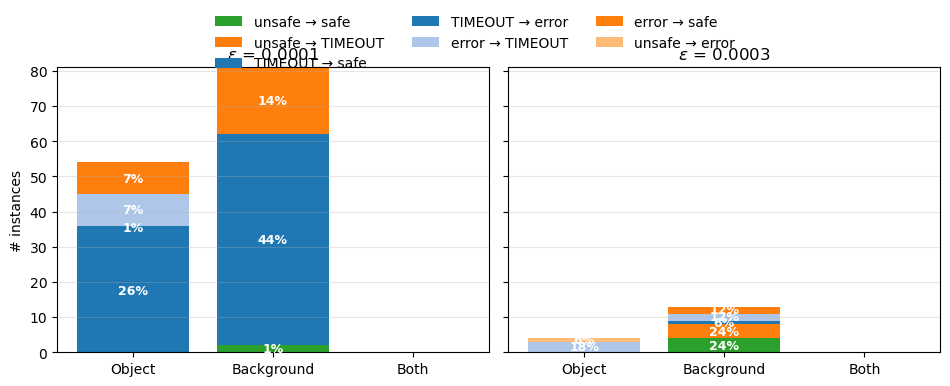

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
TARGET_K = None     # e.g. 50176, or None for "all k"
ONLY_CHANGES = True # like your figure (only transitions where global != semantic)

# Your raw results -> pretty labels
RESULT_RENAME = {
    "sat True": "Unsafe (counterexample)",
    "unsat False": "Safe (proved)",
    "timeout False": "Timeout / Unknown",
    "error": "Error",
    "sat False": "Unsafe (counterexample with BnB)",
}

# Collapse into 3 buckets for transitions (matches your plot story)
def bucket_result(raw_result: str) -> str:
    r = str(raw_result)
    if r in ("sat True", "sat False"):
        return "unsafe"
    if r == "unsat False":
        return "safe"
    if r == "timeout False":
        return "TIMEOUT"
    if r == "error":
        return "error"
    return r

# tag -> semantic category (x-axis)
# - fixnonmask => object perturbed  => "Object"
# - fixmask    => background perturbed => "Background"
# - global     => both perturbed (no semantic restriction) => "Both"
def semantic_from_tag(tag: str) -> str:
    t = str(tag).lower()
    if "fixnonmask" in t:
        return "Object"
    if "fixmask" in t:
        return "Background"
    if "_global" in t or t.endswith("global"):
        return "Both"
    return "Unknown"

# ============================================================
# 1) LOAD + CLEAN
# ============================================================
df = pd.read_csv(CSV_PATH)

df["eps"] = pd.to_numeric(df.get("eps"), errors="coerce")
df["k"]   = pd.to_numeric(df.get("k"), errors="coerce")

df["result"] = df["result"].astype(str)
df["result_pretty"] = df["result"].map(RESULT_RENAME).fillna(df["result"])
df["bucket"] = df["result"].apply(bucket_result)

df["semantic"] = df["tag"].apply(semantic_from_tag)

# optional restrict k
if TARGET_K is not None:
    df = df[df["k"] == TARGET_K].copy()

# keep only the rows we can interpret
df = df[df["semantic"].isin(["Object", "Background", "Both"])].copy()

# ============================================================
# 2) BUILD GLOBAL (Both) ANCHOR PER (image, eps, k, seg)
#    Robust to whether global rows have segment_index or not.
# ============================================================
KEY_BASE = ["image", "eps", "k"]

has_seg = "segment_index" in df.columns
if has_seg:
    # if global has no segment_index but object/background do,
    # we "broadcast" the global result to all seg ids per (image,eps,k)
    seg_ids = (
        df[df["semantic"].isin(["Object", "Background"])]
        .groupby(KEY_BASE)["segment_index"]
        .unique()
        .reset_index(name="seg_list")
    )

    global_base = (
        df[df["semantic"] == "Both"]
        .sort_values(KEY_BASE)
        .drop_duplicates(subset=KEY_BASE, keep="first")
        [KEY_BASE + ["bucket"]]
        .rename(columns={"bucket": "global_bucket"})
    )

    global_broadcast = seg_ids.merge(global_base, on=KEY_BASE, how="left")
    global_broadcast = global_broadcast.explode("seg_list").rename(columns={"seg_list": "segment_index"})
    global_broadcast["segment_index"] = pd.to_numeric(global_broadcast["segment_index"], errors="coerce")

    GLOBAL_KEYS = KEY_BASE + ["segment_index"]
    global_anchor = global_broadcast[GLOBAL_KEYS + ["global_bucket"]].copy()

else:
    GLOBAL_KEYS = KEY_BASE
    global_anchor = (
        df[df["semantic"] == "Both"]
        .sort_values(KEY_BASE)
        .drop_duplicates(subset=KEY_BASE, keep="first")
        [KEY_BASE + ["bucket"]]
        .rename(columns={"bucket": "global_bucket"})
    )

# ============================================================
# 3) COMPARE Object/Background/Both AGAINST Global
#    (Yes, we also include Both vs Global -> mostly identity, but kept for completeness)
# ============================================================
cmp = df.merge(global_anchor, on=GLOBAL_KEYS, how="left")

# If you only want semantic transitions, you may want to compare ONLY Object/Background to Global:
# cmp = cmp[cmp["semantic"].isin(["Object", "Background"])].copy()

cmp["transition"] = cmp["global_bucket"].astype(str) + " → " + cmp["bucket"].astype(str)

# filter to only rows with a matching global
cmp = cmp[cmp["global_bucket"].notna()].copy()

if ONLY_CHANGES:
    cmp = cmp[cmp["global_bucket"] != cmp["bucket"]].copy()

# ============================================================
# 4) PLOT: stacked bars per semantic category, faceted by eps
#     - one panel per eps
#     - x: Object / Background / Both
#     - stacks: ALL transitions that exist in this slice
# ============================================================
if cmp.empty:
    print("No transitions to plot (after your filters). Try ONLY_CHANGES=False or check matching keys.")
else:
    # order x-axis
    SEM_ORDER = ["Object", "Background", "Both"]

    # get eps values
    eps_values = sorted([e for e in cmp["eps"].dropna().unique()])
    n_panels = len(eps_values)

    # transition order (stable + readable)
    # Put the “interesting” ones first if they exist, then everything else.
    preferred = ["unsafe → safe", "unsafe → TIMEOUT", "TIMEOUT → safe", "safe → unsafe", "safe → TIMEOUT", "TIMEOUT → unsafe"]
    all_trans = sorted(cmp["transition"].unique())
    trans_order = [t for t in preferred if t in all_trans] + [t for t in all_trans if t not in preferred]

    # colors similar vibe to your example for the first few; fallback to tab20 cycling
    base_colors = {
        "unsafe → safe":    "#2ca02c",  # green
        "unsafe → TIMEOUT": "#ff7f0e",  # orange
        "TIMEOUT → safe":   "#1f77b4",  # blue
    }
    # generate a color map for every transition
    cmap = plt.get_cmap("tab20")
    color_map = {}
    j = 0
    for t in trans_order:
        if t in base_colors:
            color_map[t] = base_colors[t]
        else:
            color_map[t] = cmap(j % 20)
            j += 1

    fig, axes = plt.subplots(
        1, n_panels,
        figsize=(4.8 * n_panels, 3.6),
        sharey=True
    )
    if n_panels == 1:
        axes = [axes]

    for ax, eps in zip(axes, eps_values):
        d = cmp[cmp["eps"] == eps].copy()

        # counts: rows = semantic, cols = transition
        pivot = (
            d.groupby(["semantic", "transition"])
             .size()
             .unstack(fill_value=0)
             .reindex(index=SEM_ORDER, fill_value=0)
             .reindex(columns=trans_order, fill_value=0)
        )

        # stacked bars
        bottoms = np.zeros(len(pivot.index), dtype=float)
        xs = np.arange(len(pivot.index))

        for t in pivot.columns:
            vals = pivot[t].values.astype(float)
            ax.bar(xs, vals, bottom=bottoms, label=t, color=color_map.get(t, None))
            bottoms += vals

        # labels like your figure
        ax.set_xticks(xs)
        ax.set_xticklabels(pivot.index)
        ax.set_title(rf"$\epsilon$ = {eps:g}")
        ax.grid(axis="y", alpha=0.3)

        # add % text inside stacks (percent of total in THIS eps panel)
        total_panel = pivot.values.sum()
        if total_panel > 0:
            bottoms2 = np.zeros(len(pivot.index), dtype=float)
            for t in pivot.columns:
                vals = pivot[t].values.astype(float)
                for i, v in enumerate(vals):
                    if v <= 0:
                        continue
                    pct = 100.0 * v / total_panel
                    # show only if at least ~0.5% so it doesn't clutter
                    if pct >= 0.5:
                        ax.text(i, bottoms2[i] + v/2.0, f"{pct:.0f}%", ha="center", va="center",
                                color="white", fontsize=9, fontweight="bold")
                bottoms2 += vals

    axes[0].set_ylabel("# instances")

    # one shared legend on top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(3, len(labels)), frameon=False, bbox_to_anchor=(0.5, 1.08))

    fig.tight_layout()
    plt.show()